# 3.5.1 Shortest Path through an Acyclic Network

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1YPt9h3zJniGr1NpdGZutbsYBtNvX9ZfL?usp=sharing)

There are several well-known algorithms for finding the shortest path between certain pairs of nodes in a network. We will concentrate first on a particularly simple algorithm that is based on the use of recursive computations. This approach to shortest path problems will also provide us with a foundation for the study of dynamic programming and project management in the next two sections of this chapter.

&nbsp;&nbsp;&nbsp;&nbsp;As an illustration, consider the acyclic network in **Figure 3.15**, where arc labels d<sub>ij</sub> denote distance from node i to node j. Notice that in an acyclic graph, it is always possible to name the nodes in such a way that an arc is oriented from a lower-numbered node to a higher numbered node. A consequence of this property is that such a network can be represented by an adjacency matrix that is upper triangular, requiring only (n<sup>2</sup> + n)/2 storage locations in computer memory instead of n<sup>2</sup>. We wish to determine the shortest path from the lowest-numbered node to the highest-numbered node.

&nbsp;&nbsp;&nbsp;&nbsp;The algorithm operates by assigning a label to each node, indicating the shortest distance from that node to the destination. A node is *eligible* for labeling if all its successors have been labeled.

1. Initially, the destination node is given a label of zero, indicating that there is no cost or distance associated with going from that node to itself.

2. Choose any *eligible* node k, and assign it a label p<sub>k</sub> as follows:
$
p_k = \min \{ d_{kj} + p_j \},
$
the minimum taken over all successors j of node k.

3. Repeat Step 2 until the source node is labeled. The label on the source is the shortest distance from the source to the destination.

<br>

<div align="center">

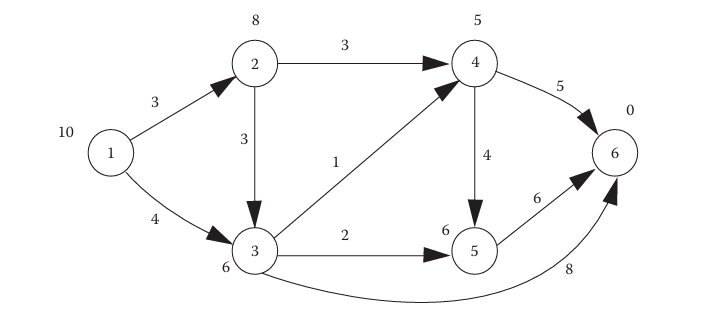

</div>

**FIGURE 3.15** <br>
Acyclic network with node labels.

<br>

In the illustration in **Figure 3.15**, initially p<sub>6</sub> = 0. Next, node 5 is eligible and p<sub>5</sub> = 6 + 0 = 6. The label for node 4 is computed as p<sub>4</sub> = min {5 + 0, 4 + 6} = 5. Node 3 is now eligible, and p<sub>3</sub> = min {1 + 5, 2 + 6, 8 + 0} = 6. The label on node 2 is p<sub>2</sub> = min {3 + 5, 3 + 6} = 8, and finally p<sub>1</sub> = min {3 + 8, 4 + 6} = 10. Thus, the length of the shortest path is 10, and the path itself is obtained by tracing back through the computation to find the path containing the arcs (1,3), (3,4), (4,6).

&nbsp;&nbsp;&nbsp;&nbsp;This backward labeling procedure has an intuitive appeal when the problem is small enough that the labels can be shown in a diagram. For larger problems, we may obtain better insight by examining the recursive structure of the computations. For this, we will again use the illustrative network from **Figure 3.15**. We wish to determine a label for node 1; but in order to compute p<sub>1</sub>, we require the labels for nodes 2 and 3. Obtaining these labels involves the recursive labeling procedure twice. Each of these recursive computations in turn requires further recursion. The pattern of recursive calls to obtain the label on the first node is illustrated as follows, where L(i) denotes p<sub>i</sub>:

<br>

$$
\begin{aligned}
L(1) &= 4 + L(3) \\[8pt]
     &= 4 + [1 + L(4)] \\[8pt]
     &= 4 + [1 + [5 + L(6)]] \\[8pt]
     &= 4 + [1 + [5 + 0]] \\[8pt]
     &= 10
\end{aligned}
$$

<br>

Observe that the label on each node summarizes information on higher-numbered nodes. In fact, the value of the label on any node is actually the length of the shortest path from that node to the destination.


In [ ]:
# ========================================
# 3.5.1 Shortest Path through an Acyclic Network
# Book Example + Algebraic Method + Ready Function
# ========================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

print('Libraries loaded successfully.')
print('NetworkX version:', nx.__version__)


Libraries loaded successfully.
NetworkX version: 3.6.1


In [ ]:
# ========================================
# Book Example — Figure 3.15
# Acyclic directed graph, nodes 1–6
# Shortest path from node 1 to node 6 = 10
# Path: 1 → 3 → 4 → 6
# ========================================

# Each edge: (from, to, weight)
edge_list = [
    (1, 2, 3),
    (1, 3, 4),
    (2, 3, 3),
    (2, 4, 3),
    (3, 4, 1),
    (3, 5, 2),
    (3, 6, 8),
    (4, 5, 4),
    (4, 6, 5),
    (5, 6, 6),
]

source      = 1
destination = 6

G = nx.DiGraph()
for u, v, w in edge_list:
    G.add_edge(u, v, weight=w)

print('Book example (Figure 3.15) network created.')
print(f'Source: {source}   Destination: {destination}')
print()
df = pd.DataFrame(edge_list, columns=['From', 'To', 'Weight'])
print(df.to_string(index=False))


Book example (Figure 3.15) network created.
Source: 1   Destination: 6

 From  To  Weight
    1   2       3
    1   3       4
    2   3       3
    2   4       3
    3   4       1
    3   5       2
    3   6       8
    4   5       4
    4   6       5
    5   6       6


In [ ]:
# ========================================
# Algebraic Method: Backward Labeling
# Assign label p_k = min{ d_kj + p_j } for each node k,
# working backward from the destination.
# This mirrors the textbook's recursive algorithm.
# ========================================

# Build adjacency dict from edge_list
adj = {n: [] for n in G.nodes()}
for u, v, w in edge_list:
    adj[u].append((v, w))

labels = {destination: 0}          # p_destination = 0
next_node_map = {destination: None}

# Process nodes in reverse topological order (destination already labeled)
topo = list(nx.topological_sort(G))
for node in reversed(topo):
    if node == destination:
        continue
    best_cost = float('inf')
    best_next = None
    for nxt, dist in adj[node]:
        if nxt in labels:           # successor already labeled
            val = dist + labels[nxt]
            if val < best_cost:
                best_cost = val
                best_next = nxt
    labels[node]       = best_cost
    next_node_map[node] = best_next

# Trace shortest path
path = [source]
cur  = source
while cur != destination:
    cur = next_node_map[cur]
    path.append(cur)

print('=== Backward-Labeling Solution ===')
print()
rows = [(n, labels[n]) for n in sorted(labels)]
display(pd.DataFrame(rows, columns=['Node', 'Label (shortest dist to dest)']))
print(f'Shortest path : {" → ".join(str(n) for n in path)}')
print(f'Total distance: {labels[source]}')
print(f'Textbook answer: 10   {chr(10004) if labels[source] == 10 else chr(10008)}')


=== Backward-Labeling Solution ===



,Node,Label (shortest dist to dest)
0,1,10
1,2,8
2,3,6
3,4,5
4,5,6
5,6,0


Shortest path : 1 → 3 → 4 → 6
Total distance: 10
Textbook answer: 10   ✔


In [ ]:
# ========================================
# Ready Function: nx.shortest_path  +  nx.shortest_path_length
# For a DAG, NetworkX uses Dijkstra by default (works for
# non-negative weights). nx.dag_shortest_path is also available
# and is specific to directed acyclic graphs.
# ========================================

# One-line solve
sp_path   = nx.shortest_path(G, source=source, target=destination, weight='weight')
sp_length = nx.shortest_path_length(G, source=source, target=destination, weight='weight')

print('=== nx.shortest_path Solution ===')
print(f'Shortest path : {" → ".join(str(n) for n in sp_path)}')
print(f'Total distance: {sp_length}')
print(f'Textbook answer: 10   {chr(10004) if sp_length == 10 else chr(10008)}')
print()

=== nx.shortest_path Solution ===
Shortest path : 1 → 3 → 4 → 6
Total distance: 10
Textbook answer: 10   ✔



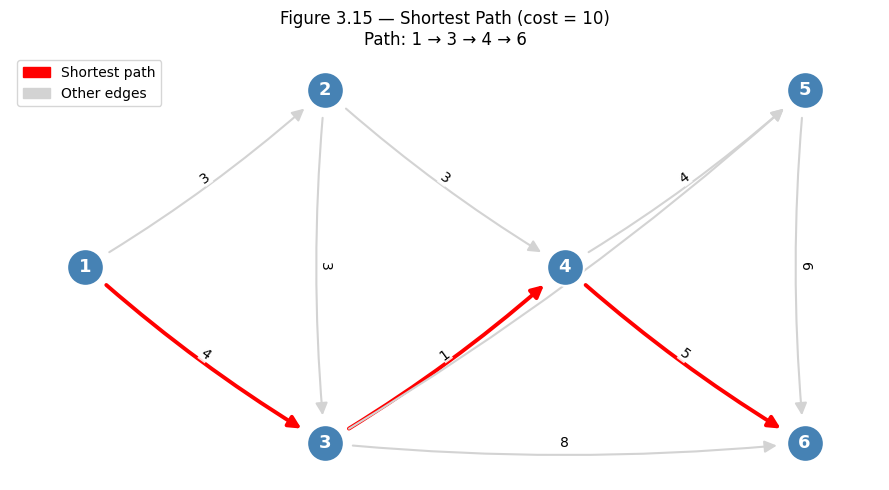

In [ ]:
# ========================================
# Draw the network (book example)
# Shortest-path edges highlighted in red
# ========================================

# Book layout matching Figure 3.15
pos_book = {
    1: (0, 1),
    2: (1, 2),
    3: (1, 0),
    4: (2, 1),
    5: (3, 2),
    6: (3, 0),
}

sp_edges = list(zip(sp_path, sp_path[1:]))
sp_set   = set(map(tuple, sp_edges))

edge_colors = ['red' if (u, v) in sp_set else 'lightgray' for u, v in G.edges()]
edge_widths = [2.8  if (u, v) in sp_set else 1.5          for u, v in G.edges()]
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}

fig, ax = plt.subplots(figsize=(9, 5))

nx.draw_networkx_nodes(G, pos_book, node_color='steelblue', node_size=700,
                       edgecolors='white', linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos_book, font_color='white',
                        font_weight='bold', font_size=13, ax=ax)
nx.draw_networkx_edges(G, pos_book, edge_color=edge_colors, width=edge_widths,
                       arrows=True, arrowstyle='-|>', arrowsize=18,
                       min_source_margin=20, min_target_margin=20,
                       connectionstyle='arc3,rad=0.05', ax=ax)
nx.draw_networkx_edge_labels(G, pos_book, edge_labels=edge_labels, font_size=10,
                             bbox=dict(facecolor='white', edgecolor='none',
                                       alpha=0.85, pad=0.2), ax=ax)

red_patch  = mpatches.Patch(color='red',       label='Shortest path')
gray_patch = mpatches.Patch(color='lightgray', label='Other edges')
ax.legend(handles=[red_patch, gray_patch], loc='upper left', fontsize=10)

path_str = ' → '.join(str(n) for n in sp_path)
ax.set_title(
    f'Figure 3.15 — Shortest Path (cost = {sp_length})\nPath: {path_str}',
    fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


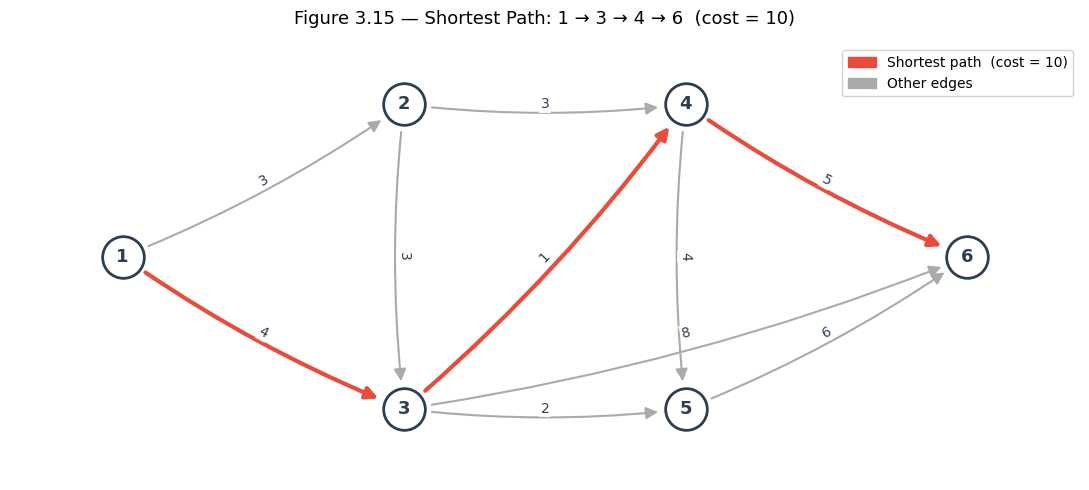

In [ ]:
# ========================================
# Draw the network (book example — Figure 3.15)
# Shortest-path edges highlighted in red
# ========================================

sp_set   = set(zip(sp_path, sp_path[1:]))
non_sp   = [(u, v) for u, v in G.edges() if (u, v) not in sp_set]
sp_edges = [(u, v) for u, v in G.edges() if (u, v) in sp_set]

# Book layout matching Figure 3.15
pos_book = {
    1: (0,  0),
    2: (2,  1.5),
    3: (2, -1.5),
    4: (4,  1.5),
    5: (4, -1.5),
    6: (6,  0),
}

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')

draw_kw = dict(arrows=True, arrowstyle='-|>', arrowsize=18,
               min_source_margin=20, min_target_margin=20,
               connectionstyle='arc3,rad=0.06', ax=ax)
nx.draw_networkx_edges(G, pos_book, edgelist=non_sp,
                       edge_color='#aaaaaa', width=1.5, **draw_kw)
nx.draw_networkx_edges(G, pos_book, edgelist=sp_edges,
                       edge_color='#e74c3c', width=3.0, **draw_kw)
nx.draw_networkx_nodes(G, pos_book, node_color='white', node_size=900,
                       edgecolors='#2c3e50', linewidths=2.0, ax=ax)
nx.draw_networkx_labels(G, pos_book, font_color='#2c3e50',
                        font_weight='bold', font_size=13, ax=ax)
nx.draw_networkx_edge_labels(
    G, pos_book,
    edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)},
    font_size=10, font_color='#2c3e50',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.0), ax=ax)

xs = [x for x, _ in pos_book.values()]
ys = [y for _, y in pos_book.values()]
ax.set_xlim(min(xs) - 0.8, max(xs) + 0.8)
ax.set_ylim(min(ys) - 0.7, max(ys) + 0.6)

path_str = ' → '.join(str(n) for n in sp_path)
red_patch  = mpatches.Patch(color='#e74c3c', label=f'Shortest path  (cost = {sp_length})')
gray_patch = mpatches.Patch(color='#aaaaaa', label='Other edges')
ax.legend(handles=[red_patch, gray_patch], loc='upper right', fontsize=10, framealpha=0.9)
ax.set_title(f'Figure 3.15 — Shortest Path: {path_str}  (cost = {sp_length})',
             fontsize=13, pad=14)
ax.axis('off')
plt.tight_layout()
plt.show()

=== Shortest Path ===
Path  : 1 → 3 → 6
Length: 12


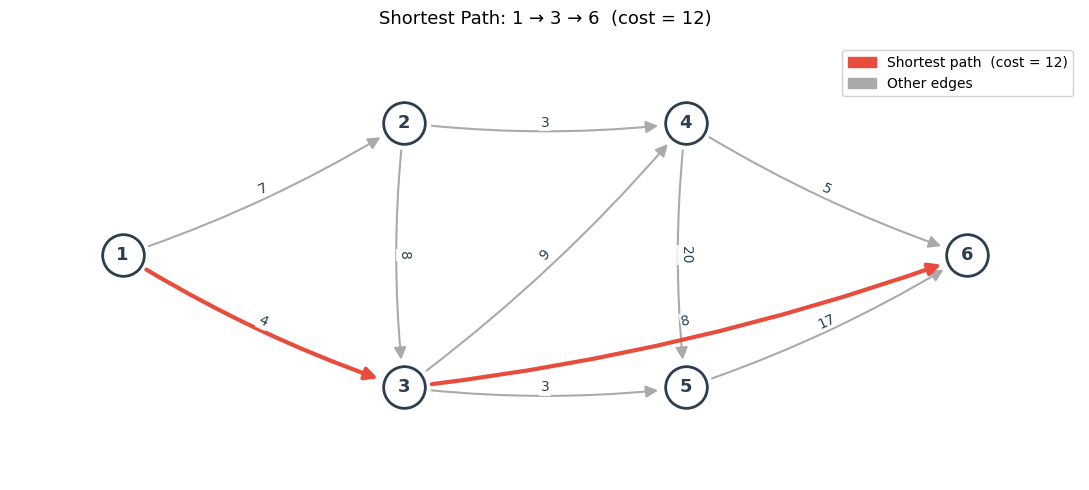

In [ ]:
# ========================================
# Your Own Acyclic Network
# Edit the edge list and source/destination, then run.
# ========================================

from collections import defaultdict

def dag_layout(G, source, target, scale=6.0, y_gap=2.0):
    """
    BFS-based left-to-right layout matching the textbook style:
    source → leftmost col, target → rightmost col (isolated),
    lower-numbered nodes on top within each column.
    Falls back to kamada_kawai for non-DAG graphs.
    """
    if not nx.is_directed_acyclic_graph(G):
        return nx.kamada_kawai_layout(G, weight=None)
    layers = {source: 0}
    for u, v in nx.bfs_edges(G, source):
        layers[v] = layers[u] + 1
    inner = [n for n in layers if n != source and n != target]
    layers[target] = (max(layers[n] for n in inner) + 1) if inner else 1
    layer_nodes = defaultdict(list)
    for node, lyr in layers.items():
        layer_nodes[lyr].append(node)
    for lyr in layer_nodes:
        layer_nodes[lyr].sort()
    n_layers = max(layer_nodes.keys()) + 1
    pos = {}
    for lyr, nodes in layer_nodes.items():
        n = len(nodes)
        x = (lyr / (n_layers - 1)) * scale if n_layers > 1 else scale / 2
        for i, node in enumerate(nodes):
            pos[node] = (x, -(i - (n - 1) / 2) * y_gap)
    return pos


# ── Step 1: Define your edges (from, to, weight) ─────────────────────────────
custom_edges = [
    (1, 2, 7),
    (1, 3, 4),
    (2, 3, 8),
    (2, 4, 3),
    (3, 4, 9),
    (3, 5, 3),
    (3, 6, 8),
    (4, 5, 20),
    (4, 6, 5),
    (5, 6, 17),
]
custom_source = 1
custom_dest   = 6

# ── Step 2: Build graph ───────────────────────────────────────────────────────
G_c = nx.DiGraph()
for u, v, w in custom_edges:
    G_c.add_edge(u, v, weight=w)

# ── Step 3: Solve ─────────────────────────────────────────────────────────────
c_path   = nx.shortest_path(G_c, source=custom_source, target=custom_dest, weight='weight')
c_length = nx.shortest_path_length(G_c, source=custom_source, target=custom_dest, weight='weight')

print('=== Shortest Path ===')
print(f'Path  : {" → ".join(str(n) for n in c_path)}')
print(f'Length: {c_length}')

# ── Step 4: Layout & draw ─────────────────────────────────────────────────────
pos_c    = dag_layout(G_c, custom_source, custom_dest)
c_sp_set = set(zip(c_path, c_path[1:]))
non_sp   = [(u, v) for u, v in G_c.edges() if (u, v) not in c_sp_set]
sp       = [(u, v) for u, v in G_c.edges() if (u, v) in c_sp_set]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')

draw_kw = dict(arrows=True, arrowstyle='-|>', arrowsize=18,
               min_source_margin=20, min_target_margin=20,
               connectionstyle='arc3,rad=0.06', ax=ax)
nx.draw_networkx_edges(G_c, pos_c, edgelist=non_sp,
                       edge_color='#aaaaaa', width=1.5, **draw_kw)
nx.draw_networkx_edges(G_c, pos_c, edgelist=sp,
                       edge_color='#e74c3c', width=3.0, **draw_kw)
nx.draw_networkx_nodes(G_c, pos_c, node_color='white', node_size=900,
                       edgecolors='#2c3e50', linewidths=2.0, ax=ax)
nx.draw_networkx_labels(G_c, pos_c, font_color='#2c3e50',
                        font_weight='bold', font_size=13, ax=ax)
nx.draw_networkx_edge_labels(
    G_c, pos_c,
    edge_labels={(u, v): d['weight'] for u, v, d in G_c.edges(data=True)},
    font_size=10, font_color='#2c3e50',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.0), ax=ax)

xs = [x for x, _ in pos_c.values()]
ys = [y for _, y in pos_c.values()]
ax.set_xlim(min(xs) - 0.8, max(xs) + 0.8)
ax.set_ylim(min(ys) - 0.7, max(ys) + 0.6)

path_str_c = ' → '.join(str(n) for n in c_path)
red_patch  = mpatches.Patch(color='#e74c3c', label=f'Shortest path  (cost = {c_length})')
gray_patch = mpatches.Patch(color='#aaaaaa', label='Other edges')
ax.legend(handles=[red_patch, gray_patch], loc='upper right', fontsize=10, framealpha=0.9)
ax.set_title(f'Shortest Path: {path_str_c}  (cost = {c_length})', fontsize=13, pad=14)
ax.axis('off')
plt.tight_layout()
plt.show()